In [1]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yfin
from datetime import date

pd.options.display.float_format="{:,.6f}".format

In [2]:
start = datetime.date(2019,3,25)
end = datetime.date(2026,3,25)

In [3]:
df_bc = yfin.download(['BTC-USD'], start=start, end=end, auto_adjust=False)['Adj Close']
df_bc.index = df_bc.index.tz_localize('UTC')
df_bc.head()

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2019-03-25 00:00:00+00:00,"3,963.070557"
2019-03-26 00:00:00+00:00,"3,985.080811"
2019-03-27 00:00:00+00:00,"4,087.066162"
2019-03-28 00:00:00+00:00,"4,069.107178"
2019-03-29 00:00:00+00:00,"4,098.374512"


In [4]:
df_bc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-03-25 00:00:00+00:00 to 2026-03-24 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB


In [5]:
url="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Guaranty%20Trust%20Holding%20Stock%20Price%20History.csv"
df_g = pd.read_csv(url, parse_dates=['Date'], index_col='Date')['Price']
df_g.index = df_g.index.tz_localize('UTC')
df_g.rename('GTCO', inplace=True)
df_g = df_g.sort_index(ascending=True)
df_g.head()

,GTCO
Date,
2019-03-25 00:00:00+00:00,37.500000
2019-03-26 00:00:00+00:00,37.400000
2019-03-27 00:00:00+00:00,36.000000
2019-03-28 00:00:00+00:00,36.900000
2019-03-29 00:00:00+00:00,36.050000


In [6]:
url1="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Zenith%20Bank%20Stock%20Price%20History.csv"
df_z = pd.read_csv(url1, parse_dates=['Date'], index_col='Date')['Price']
df_z.index = df_z.index.tz_localize('UTC')
df_z.rename('ZENITHBANK', inplace=True)
df_z = df_z.sort_index(ascending=True)
df_z.head()

,ZENITHBANK
Date,
2019-03-25 00:00:00+00:00,21.500000
2019-03-26 00:00:00+00:00,21.700000
2019-03-27 00:00:00+00:00,22.000000
2019-03-28 00:00:00+00:00,21.800000
2019-03-29 00:00:00+00:00,21.800000


In [7]:
print(df_z.info())
print(" \n")
print(df_bc.info())
print(" \n")
print(df_g.info())


<class 'pandas.core.series.Series'>
DatetimeIndex: 1733 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: ZENITHBANK
Non-Null Count  Dtype  
--------------  -----  
1733 non-null   float64
dtypes: float64(1)
memory usage: 27.1 KB
None
 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-03-25 00:00:00+00:00 to 2026-03-24 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB
None
 

<class 'pandas.core.series.Series'>
DatetimeIndex: 1728 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: GTCO
Non-Null Count  Dtype  
--------------  -----  
1728 non-null   float64
dtypes: float64(1)
memory usage: 27.0 KB
None


In [8]:
df = df_bc.merge(df_z, left_index=True, right_index=True, how='outer')\
    .merge(df_g, left_index=True, right_index=True, how='outer')

print(df.shape)
print("\n")
print(df.head(10))

(2558, 3)


                               BTC-USD  ZENITHBANK      GTCO
Date                                                        
2019-03-25 00:00:00+00:00 3,963.070557   21.500000 37.500000
2019-03-26 00:00:00+00:00 3,985.080811   21.700000 37.400000
2019-03-27 00:00:00+00:00 4,087.066162   22.000000 36.000000
2019-03-28 00:00:00+00:00 4,069.107178   21.800000 36.900000
2019-03-29 00:00:00+00:00 4,098.374512   21.800000 36.050000
2019-03-30 00:00:00+00:00 4,106.660156         NaN       NaN
2019-03-31 00:00:00+00:00 4,105.404297         NaN       NaN
2019-04-01 00:00:00+00:00 4,158.183105   21.900000 36.000000
2019-04-02 00:00:00+00:00 4,879.877930   21.300000 36.000000
2019-04-03 00:00:00+00:00 4,973.021973   20.400000 35.000000


In [9]:
df_test = df.copy()
df_test.head()

,BTC-USD,ZENITHBANK,GTCO
Date,,,
2019-03-25 00:00:00+00:00,"3,963.070557",21.500000,37.500000
2019-03-26 00:00:00+00:00,"3,985.080811",21.700000,37.400000
2019-03-27 00:00:00+00:00,"4,087.066162",22.000000,36.000000
2019-03-28 00:00:00+00:00,"4,069.107178",21.800000,36.900000
2019-03-29 00:00:00+00:00,"4,098.374512",21.800000,36.050000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BTC-USD     2557 non-null   float64
 1   ZENITHBANK  1733 non-null   float64
 2   GTCO        1728 non-null   float64
dtypes: float64(3)
memory usage: 79.9 KB


In [11]:
df.describe()

,BTC-USD,ZENITHBANK,GTCO
count,"2,557.000000","1,733.000000","1,728.000000"
mean,"43,898.502923",32.109019,40.145284
std,"32,162.238074",16.600227,23.012930
min,"3,963.070557",10.700000,16.750000
25%,"16,848.126953",21.300000,25.500000
50%,"36,575.140625",25.000000,30.800000
75%,"64,096.199219",37.600000,45.462500
max,"124,752.531250",111.150000,123.500000


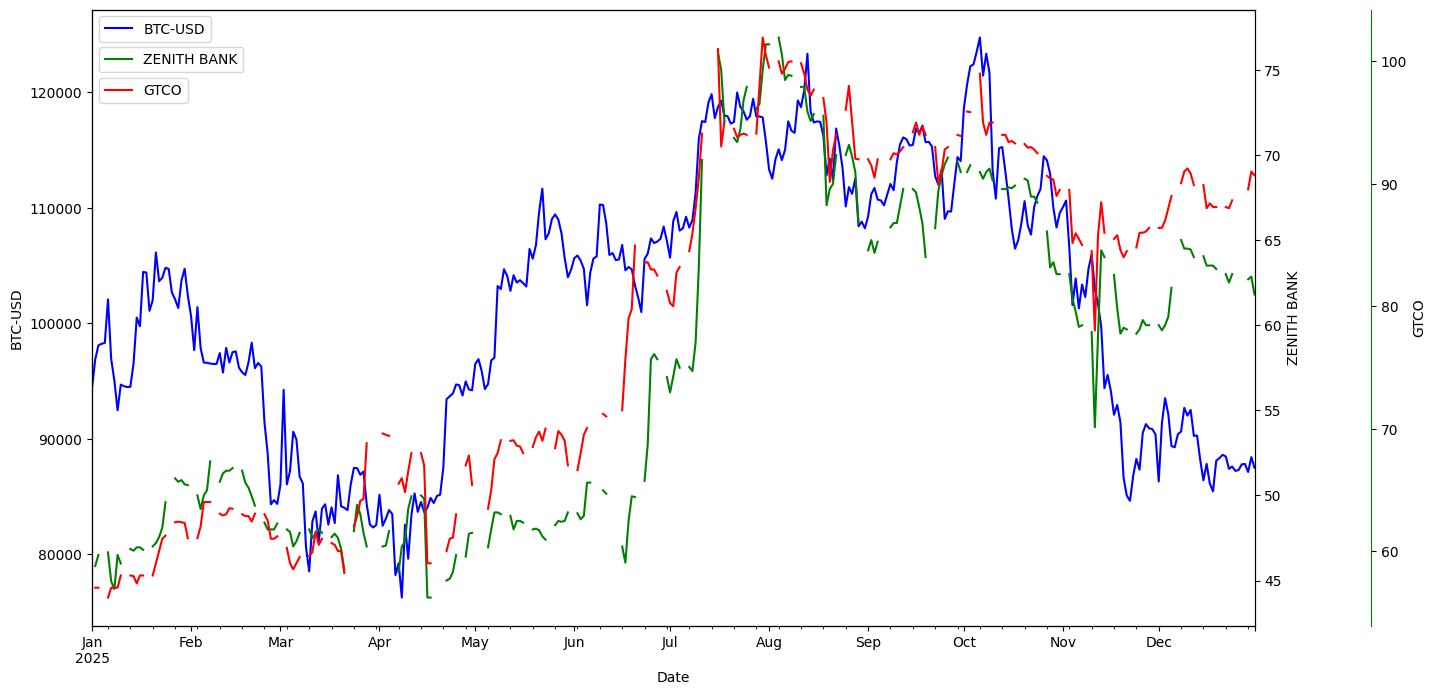

In [12]:
from matplotlib import legend
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines['right'].set_position(('axes', 1.1))
ax3.spines['right'].set_color('green')

df['2025-01-01': '2025-12-31'].plot(ax=ax1, y='BTC-USD', color='blue', label='BTC-USD', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax2, y="ZENITHBANK", color="green", label ='ZENITH BANK', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax3, y="GTCO", color="red", label ='GTCO', legend=True)

ax1.set_ylabel('BTC-USD')
ax2.set_ylabel('ZENITH BANK')
ax3.set_ylabel('GTCO')

ax1.set_xlabel('Date')

ax1.legend(['BTC-USD'], loc='upper left')
ax2.legend(['ZENITH BANK'], loc='upper left',  bbox_to_anchor=(0, 0.95))
ax3.legend(['GTCO'], loc='upper left', bbox_to_anchor=(0, 0.9))

plt.show()

In [13]:
df_return = np.log(df / df.shift(1)).dropna()
df_return.head(10)

,BTC-USD,ZENITHBANK,GTCO
Date,,,
2019-03-26 00:00:00+00:00,0.005538,0.009259,-0.002670
2019-03-27 00:00:00+00:00,0.025270,0.013730,-0.038152
2019-03-28 00:00:00+00:00,-0.004404,-0.009132,0.024693
2019-03-29 00:00:00+00:00,0.007167,0.000000,-0.023305
2019-04-02 00:00:00+00:00,0.160042,-0.027780,0.000000
2019-04-03 00:00:00+00:00,0.018907,-0.043172,-0.028171
2019-04-04 00:00:00+00:00,-0.010150,0.004890,0.000000
2019-04-05 00:00:00+00:00,0.022870,-0.007344,0.000000
2019-04-09 00:00:00+00:00,-0.016163,-0.002478,0.000000


In [14]:
avg_annual_return = df_return.mean() * 252
avg_annual_return

,0
BTC-USD,0.216950
ZENITHBANK,0.246501
GTCO,0.214723


In [15]:
avg_daily_return = df_return.mean()
avg_daily_return

,0
BTC-USD,0.000861
ZENITHBANK,0.000978
GTCO,0.000852


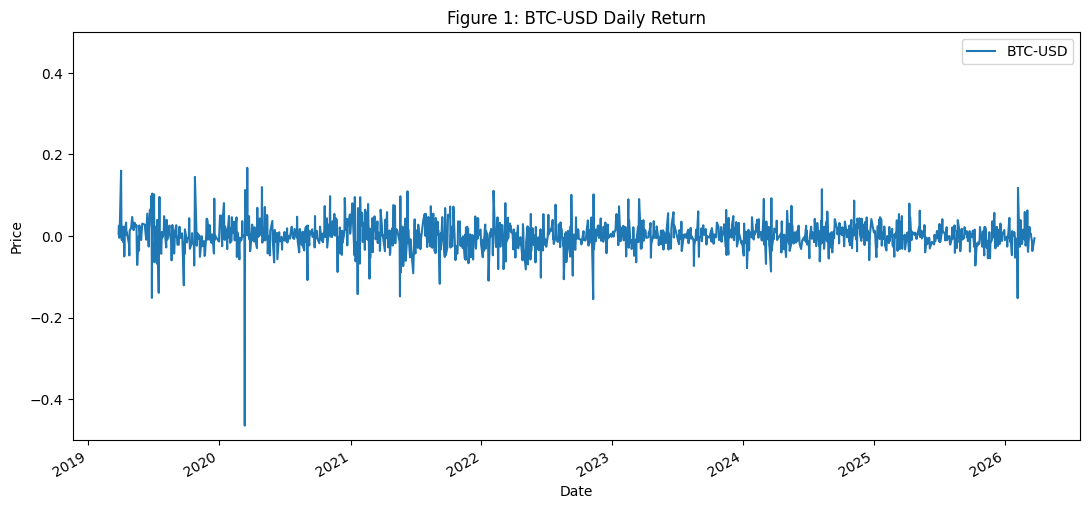

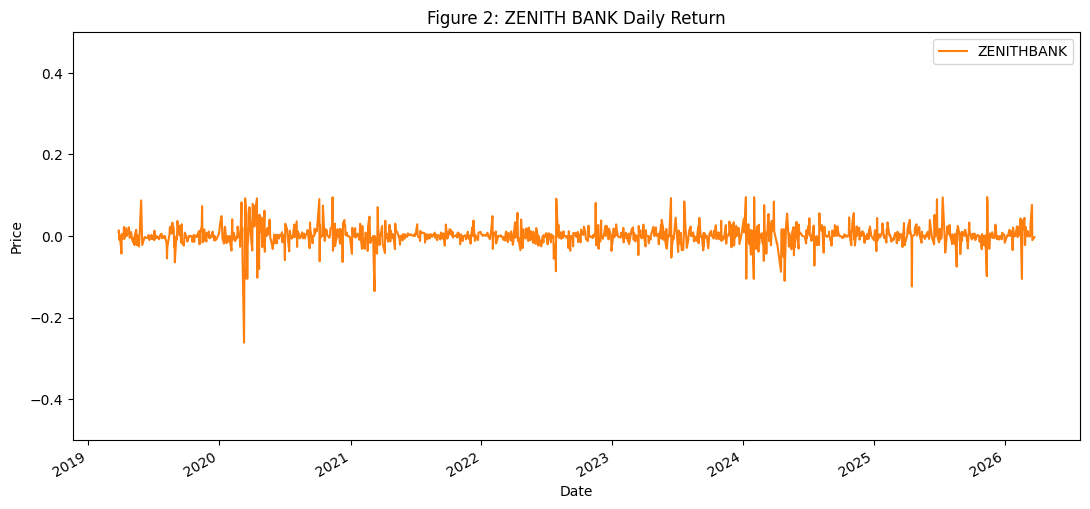

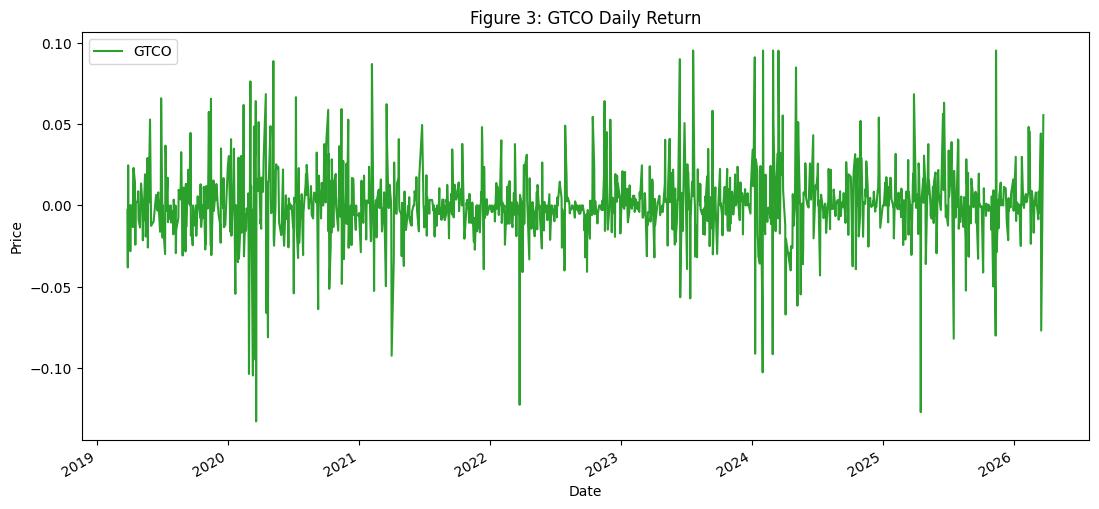

In [16]:
ax1 = df_return.plot(figsize=(13,6), y='BTC-USD', title='Figure 1: BTC-USD Daily Return')
ax2 = df_return.plot(figsize=(13,6), y='ZENITHBANK', title='Figure 2: ZENITH BANK Daily Return', c="C1")
ax3 = df_return.plot(figsize=(13,6), y='GTCO', title='Figure 3: GTCO Daily Return', c="C2")

ax1.set_ylabel('Price')
ax1.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.set_xlabel('Date')
ax3.set_ylabel('Price')
ax3.set_xlabel('Date')


ax1.set_ylim(-0.5, 0.5)
ax2.set_ylim(-0.5, 0.5)

plt.show()

In [17]:
df.tail()

,BTC-USD,ZENITHBANK,GTCO
Date,,,
2026-03-21 00:00:00+00:00,"68,711.523438",NaN,NaN
2026-03-22 00:00:00+00:00,"67,845.210938",NaN,NaN
2026-03-23 00:00:00+00:00,"70,914.859375",107.500000,105.000000
2026-03-24 00:00:00+00:00,"70,517.859375",107.200000,111.000000
2026-03-25 00:00:00+00:00,NaN,106.850000,114.550000


In [18]:
#High_low Volatility BTC

end = pd.Timestamp(df.index[-2])
curr_year = df.loc[end - pd.Timedelta(days=365) : end]

(curr_year.max() - curr_year.min())/df.iloc[-2]

,0
BTC-USD,0.879925
ZENITHBANK,0.626399
GTCO,0.581081


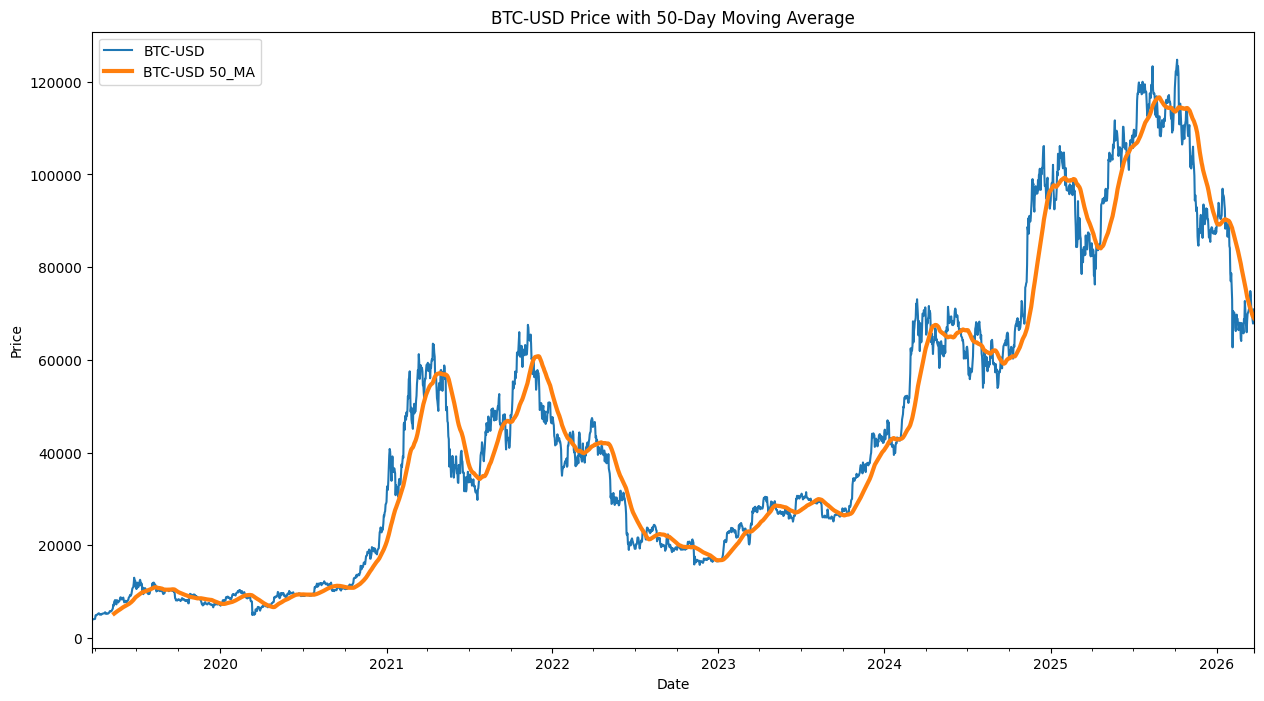

In [19]:
#Moving Average BTC

df['BTC-USD 50_MA'] = df['BTC-USD'].rolling(window=50).mean()

plt.figure(figsize=(15,8))
df["BTC-USD"].plot(label="BTC-USD")
df['BTC-USD 50_MA'].plot(label="BTC-USD 50_MA", linewidth=3)
plt.legend()
plt.title('BTC-USD Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

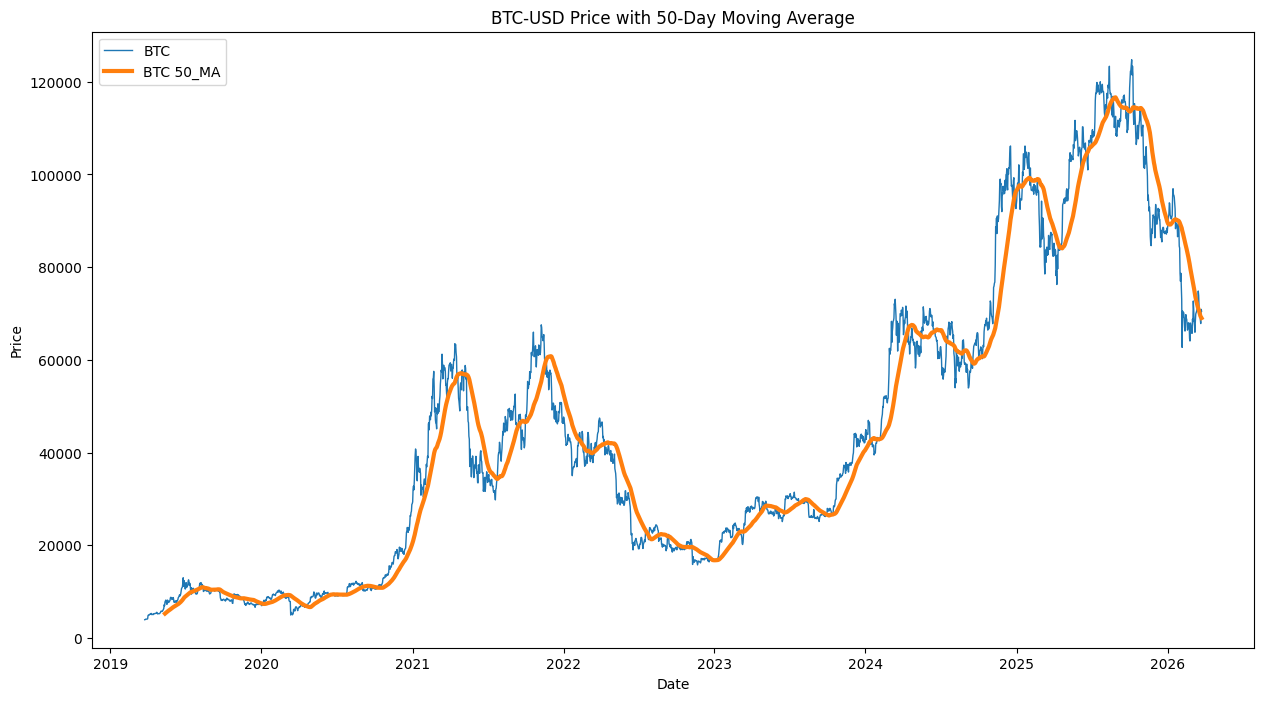

In [20]:
# Moving Avg ZENITH
df['BTC 50_MA'] = df['BTC-USD'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(df.index, df['BTC-USD'], label='BTC', linewidth=1)
plt.plot(df.index, df['BTC 50_MA'], label='BTC 50_MA',
         linewidth=3)

plt.legend()
plt.title('BTC-USD Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

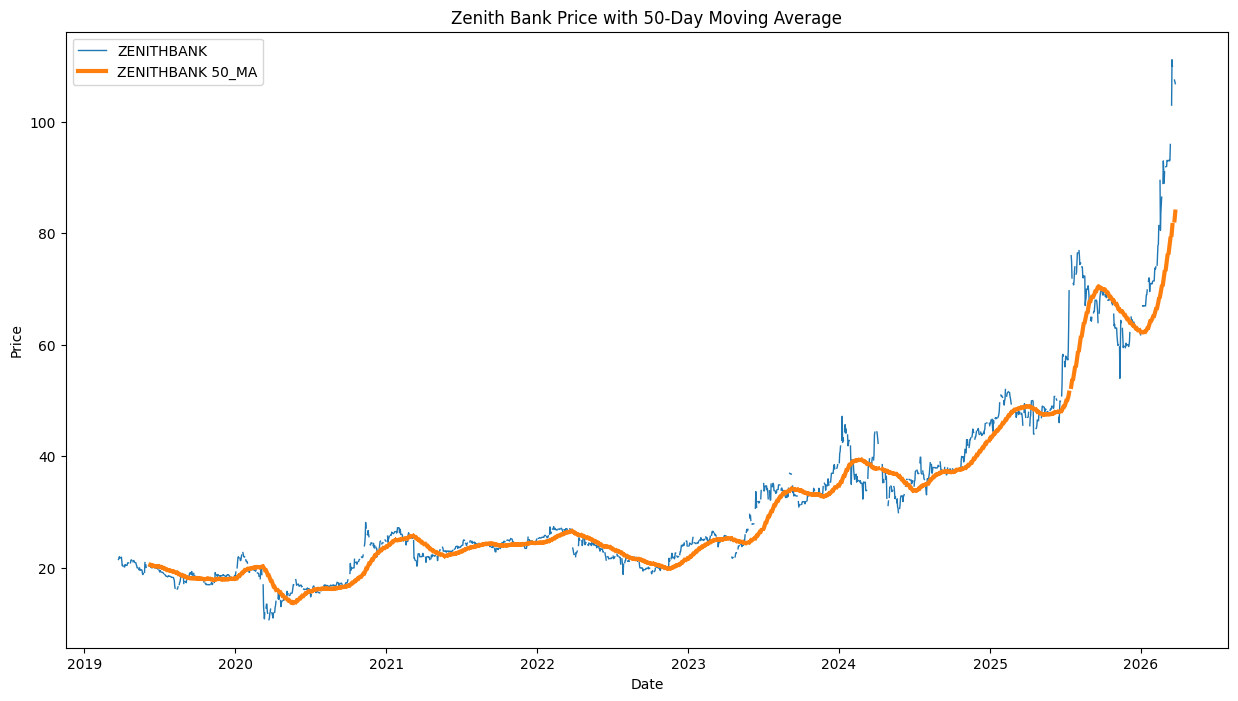

In [21]:
# Moving Avg ZENITH
df['ZENITHBANK 50_MA'] = df['ZENITHBANK'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(df.index, df['ZENITHBANK'], label='ZENITHBANK', linewidth=1)
plt.plot(df.index, df['ZENITHBANK 50_MA'], label='ZENITHBANK 50_MA',
         linewidth=3)

plt.legend()
plt.title('Zenith Bank Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

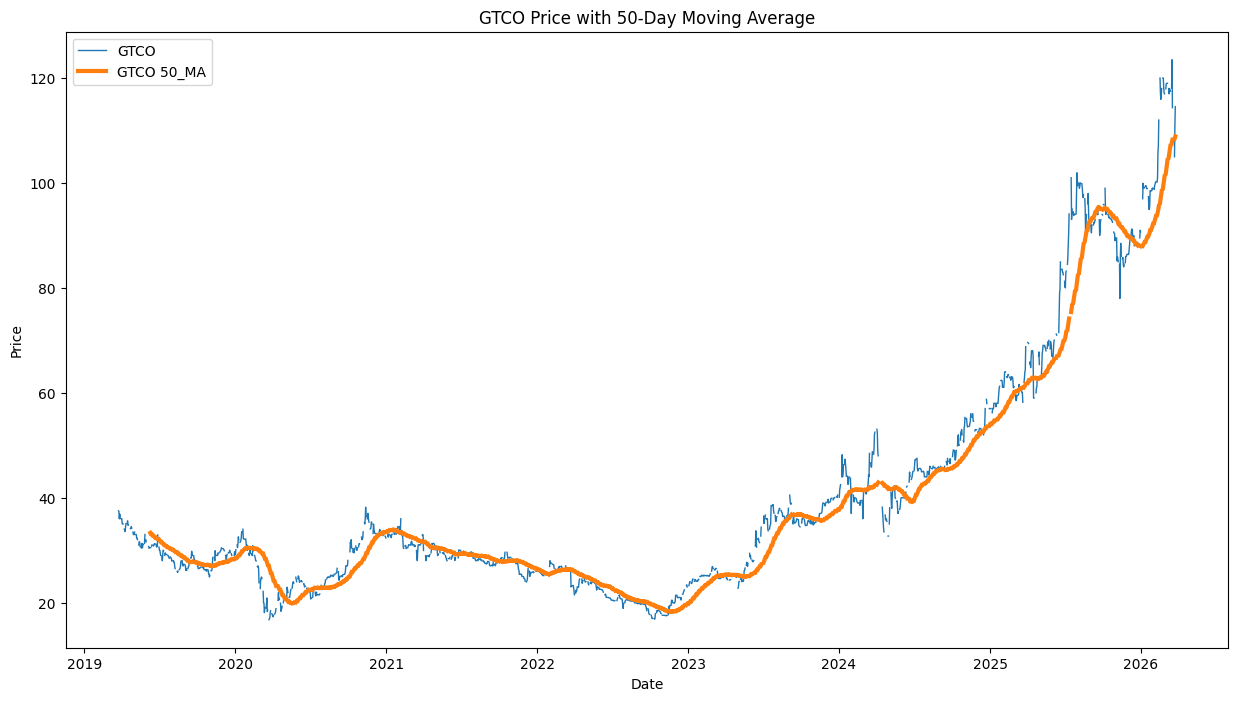

In [22]:
# Moving Average GTCO

df['GTCO 50_MA'] = df['GTCO'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))
plt.plot(df.index, df['GTCO'], label='GTCO', linewidth=1)
plt.plot(df.index, df['GTCO 50_MA'], label='GTCO 50_MA',
         linewidth=3)

plt.legend()
plt.title('GTCO Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [23]:
# Rolling distance

(abs(df - df.dropna().rolling(window=50).mean())/df).mean()

,0
BTC-USD,0.129703
ZENITHBANK,0.069223
GTCO,0.070383
BTC-USD 50_MA,0.110539
BTC 50_MA,0.110539
ZENITHBANK 50_MA,0.050134
GTCO 50_MA,0.053114


In [24]:
# Standard Deviations

df_return.std()

,0
BTC-USD,0.036261
ZENITHBANK,0.024223
GTCO,0.022267


In [25]:
# sharpe ratio

sharpe_ratio = np.sqrt(252) * (df_return.mean() / df_return.std())
sharpe_ratio

,0
BTC-USD,0.376893
ZENITHBANK,0.641051
GTCO,0.607449


In [26]:
# Semivariance

mean_returns = df_return.mean()
semivariance = (df_return[df_return < mean_returns] - mean_returns)**2
semi_var = semivariance.mean()

semi_var

,0
BTC-USD,0.001381
ZENITHBANK,0.000570
GTCO,0.000449


In [27]:
def InvestmentComparison(startTime, endTime, df):
  startTime = pd.Timestamp(startTime).tz_localize('UTC')
  endTime = pd.Timestamp(endTime).tz_localize('UTC')

  returns = np.log(df)-np.log(df.shift(1))
  returns = returns.iloc[1:, 0:]

  curr_year= df.loc[endTime - pd.Timedelta(days=365) : endTime]


  highlow_series = (curr_year.max() - curr_year.min()) / df.iloc[-2]


  # Calculate MA as a Series, considering only original asset columns
  ma_series = (abs(df - df.dropna().rolling(window=50).mean())/df).mean()

  # Calculate std as a Series
  std_series = returns.std()

  # Calculate daily return as a Series
  daily_return_series = returns.mean()

  # Sharpe ratio
  sharpe_ratio = np.sqrt(252) * (daily_return_series / std_series)

  # Semi-variance
  mean_returns = df_return.mean()
  semivariance = (df_return[df_return < mean_returns] - mean_returns)**2
  semi_var = semivariance.mean()

  # Combine all Series into a single DataFrame
  investment = pd.DataFrame({
      'highlow': highlow_series,
      'MA': ma_series,
      'std': std_series,
      'daily return': daily_return_series,
      'sharpe ratio': sharpe_ratio,
      'semi-variance': semi_var
  })

  # Format the columns
  investment['highlow'] = investment['highlow'].round(4).astype(str)

  # Format other columns as percentages
  for col_name in ["std", "daily return", 'MA']:
    investment[col_name] = (investment[col_name]*100).round(3).astype(str) + '%'

  return investment

In [28]:
InvestmentComparison('2020-01-01', '2026-01-01', df_test)

,highlow,MA,std,daily return,sharpe ratio,semi-variance
BTC-USD,0.6875,13.111%,3.305%,0.113%,0.540933,0.001381
ZENITHBANK,0.3069,6.886%,2.418%,0.098%,0.641965,0.000570
GTCO,0.4122,7.041%,2.227%,0.087%,0.623573,0.000449


In [29]:
InvestmentComparison('2024-01-01', '2025-01-01', df_test)

,highlow,MA,std,daily return,sharpe ratio,semi-variance
BTC-USD,0.9449,13.111%,3.305%,0.113%,0.540933,0.001381
ZENITHBANK,0.1613,6.886%,2.418%,0.098%,0.641965,0.000570
GTCO,0.2347,7.041%,2.227%,0.087%,0.623573,0.000449


In [30]:
# Covariance

df_return.cov()

,BTC-USD,ZENITHBANK,GTCO
BTC-USD,0.001315,0.000020,0.000012
ZENITHBANK,0.000020,0.000587,0.000321
GTCO,0.000012,0.000321,0.000496


In [31]:
# Correlation

df_return.corr()

,BTC-USD,ZENITHBANK,GTCO
BTC-USD,1.000000,0.022697,0.015138
ZENITHBANK,0.022697,1.000000,0.594895
GTCO,0.015138,0.594895,1.000000


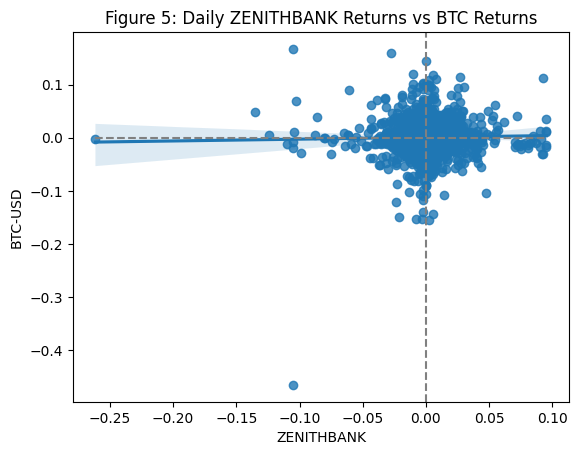

In [32]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="ZENITHBANK", y="BTC-USD", data=df_return).set(
    title="Figure 5: Daily ZENITHBANK Returns vs BTC Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['ZENITHBANK']), max(df_return['ZENITHBANK'])], [0, 0], linestyle="--", color="grey");

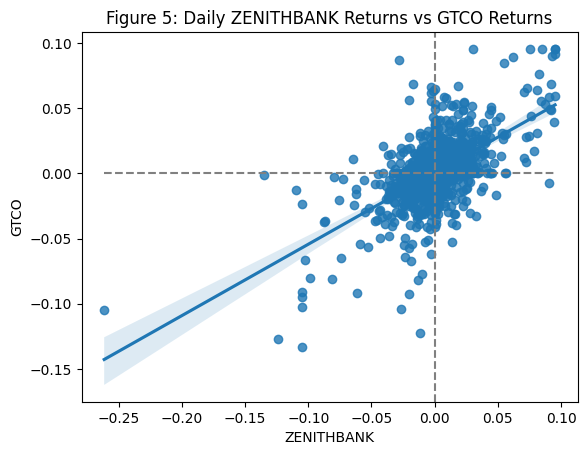

In [33]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="ZENITHBANK", y="GTCO", data=df_return).set(
    title="Figure 5: Daily ZENITHBANK Returns vs GTCO Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['ZENITHBANK']), max(df_return['ZENITHBANK'])], [0, 0], linestyle="--", color="grey");

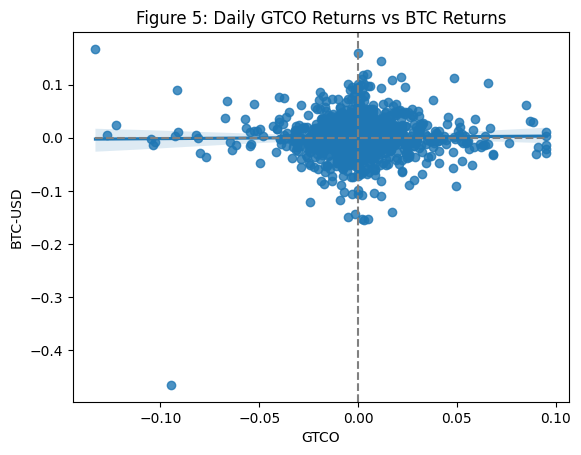

In [34]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="GTCO", y="BTC-USD", data=df_return).set(
    title="Figure 5: Daily GTCO Returns vs BTC Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['GTCO']), max(df_return['GTCO'])], [0, 0], linestyle="--", color="grey");

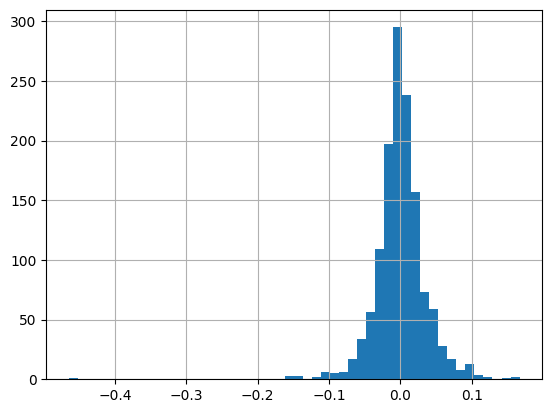

In [35]:
df_return['BTC-USD'].hist(bins=50);

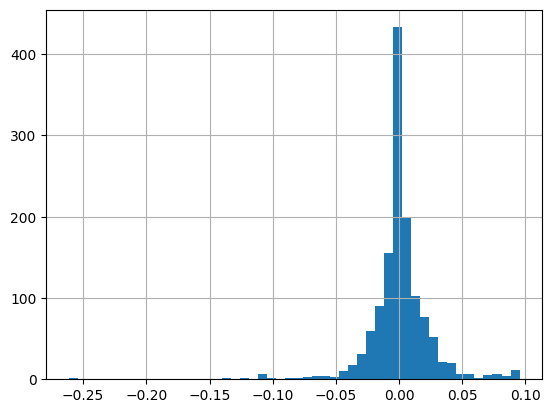

In [36]:
df_return["ZENITHBANK"].hist(bins=50);

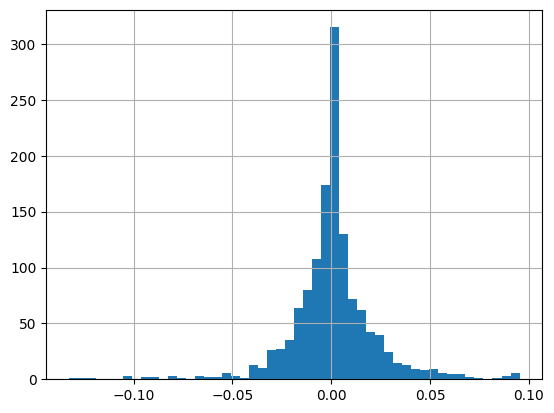

In [37]:
df_return["GTCO"].hist(bins=50);

In [38]:
from scipy import stats

In [39]:
#D'Agostino and Pearson's normality test

stats.normaltest(df_return['BTC-USD'])

NormaltestResult(statistic=np.float64(653.4056927880705), pvalue=np.float64(1.3024365912507122e-142))

In [40]:
stats.normaltest(df_return['ZENITHBANK'])

NormaltestResult(statistic=np.float64(484.9700779825438), pvalue=np.float64(4.898753897276861e-106))

In [41]:
stats.normaltest(df_return['GTCO'])

NormaltestResult(statistic=np.float64(205.53857944640296), pvalue=np.float64(2.3327304805594384e-45))

In [42]:
# Jacque bera

stats.jarque_bera(df_return['BTC-USD'])

SignificanceResult(statistic=np.float64(28058.379908800074), pvalue=np.float64(0.0))

In [43]:
stats.jarque_bera(df_return['ZENITHBANK'])

SignificanceResult(statistic=np.float64(13487.243133894619), pvalue=np.float64(0.0))

In [44]:
stats.jarque_bera(df_return['GTCO'])

SignificanceResult(statistic=np.float64(2404.3238150158086), pvalue=np.float64(0.0))

In [45]:
# minimum and maximum daily log returns
dfMax = df_return['ZENITHBANK'].max()
dfMin = df_return['ZENITHBANK'].min()

# Print maximum and minimum daily log returns
print("Maximum return of sample data is: ", round(dfMax, 5))
print("Minimum return of sample data is: ", round(dfMin, 5))
print(' - - - - - - - - - -')

# Calculates the number of standard deviations from the mean return
num_dev_max = (df_return['ZENITHBANK'].max() - df_return['ZENITHBANK'].mean()) / df_return['ZENITHBANK'].std()
num_dev_min = (df_return['ZENITHBANK'].min() - df_return['ZENITHBANK'].mean()) / df_return['ZENITHBANK'].std()

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))

Maximum return of sample data is:  0.09531
Minimum return of sample data is:  -0.26148
 - - - - - - - - - -
Number of standard deviations from the mean for the maximum return:  3.89434
Number of standard deviations from the mean for the minimum return:  -10.83513


In [46]:
stats.norm.cdf(-10.85213)

np.float64(9.74156552742683e-28)

In [47]:
# Calculates the upper and lowers bounds
upper = (3 * df_return['ZENITHBANK'].std()) + df_return['ZENITHBANK'].mean()
lower = (-3 * df_return['ZENITHBANK'].std()) + df_return['ZENITHBANK'].mean()

# Print the results
print("Upper bound: ", round(upper, 5))
print("Lower bound: ", round(lower, 5))

Upper bound:  0.07365
Lower bound:  -0.07169


In [48]:
# Calculates the number of data points
len(df_return[(df_return['ZENITHBANK'] < lower) | (df_return['ZENITHBANK'] > upper)])

39

In [49]:
# minimum and maximum daily log returns
dfMax = df_return['GTCO'].max()
dfMin = df_return['GTCO'].min()

# Print maximum and minimum daily log returns
print("Maximum return of sample data is: ", round(dfMax, 5))
print("Minimum return of sample data is: ", round(dfMin, 5))
print(' - - - - - - - - - -')

# Calculates the number of standard deviations from the mean return
num_dev_max = (df_return['GTCO'].max() - df_return['GTCO'].mean()) / df_return['GTCO'].std()
num_dev_min = (df_return['GTCO'].min() - df_return['GTCO'].mean()) / df_return['GTCO'].std()

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))

Maximum return of sample data is:  0.09531
Minimum return of sample data is:  -0.13285
 - - - - - - - - - -
Number of standard deviations from the mean for the maximum return:  4.242
Number of standard deviations from the mean for the minimum return:  -6.00432


In [50]:
stats.norm.cdf(-6.00432)

np.float64(9.606771627286962e-10)

In [51]:
# Calculates the upper and lowers bounds
upper = (3 * df_return['GTCO'].std()) + df_return['GTCO'].mean()
lower = (-3 * df_return['GTCO'].std()) + df_return['GTCO'].mean()

# Print the results
print("Upper bound: ", round(upper, 5))
print("Lower bound: ", round(lower, 5))

Upper bound:  0.06765
Lower bound:  -0.06595


In [52]:
# Calculates the number of data points
len(df_return[(df_return['GTCO'] < lower) | (df_return['GTCO'] > upper)])

29

Original rows: 1336
After removing zeros: 1154
count   1,154.000000
mean        0.001132
std         0.026061
min        -0.261480
25%        -0.008466
50%         0.001629
75%         0.010865
max         0.095310
Name: ZENITHBANK, dtype: float64

Fitted parameters: df=2.12, loc=0.000722, scale=0.012717


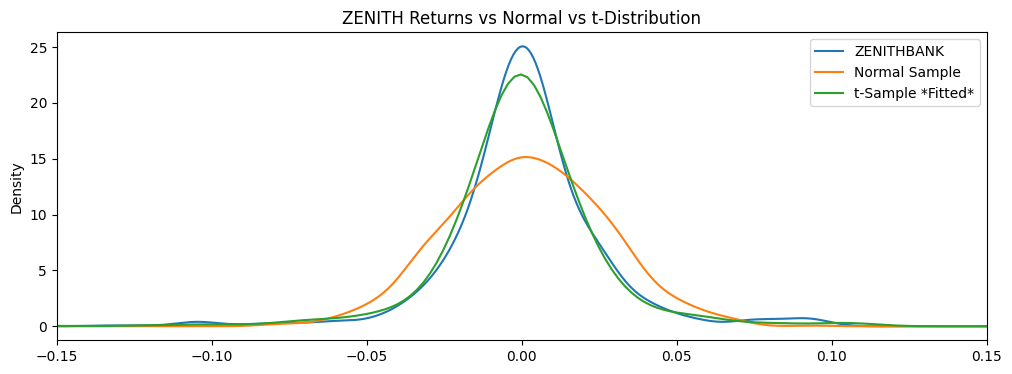

In [53]:
# Step 1: Remove zero returns before fitting
zenith_returns = df_return['ZENITHBANK']
zenith_clean = zenith_returns[zenith_returns != 0].dropna()

print(f"Original rows: {len(zenith_returns)}")
print(f"After removing zeros: {len(zenith_clean)}")
print(zenith_clean.describe())

# Step 2: Fit t-distribution to cleaned returns
params = stats.t.fit(zenith_clean)
print(f"\nFitted parameters: df={params[0]:.2f}, loc={params[1]:.6f}, scale={params[2]:.6f}")

# Step 3: Generate fitted samples
fitted_samples = stats.t.rvs(*params, size=len(zenith_clean))

# Step 4: Normal distribution sample for comparison
normal_samples = np.random.normal(
    loc=zenith_clean.mean(),
    scale=zenith_clean.std(),
    size=len(zenith_clean)
)

# Step 5: Plot
plot_df = pd.DataFrame({
    'ZENITHBANK': zenith_clean.values,
    'Normal Sample': normal_samples,
    't-Sample *Fitted*': fitted_samples
})

plot_df.plot(kind='kde', figsize=(12, 4), xlim=(-0.15, 0.15))
plt.title('ZENITH Returns vs Normal vs t-Distribution')
plt.show()

Original rows: 1336
After removing zeros: 1169
count   1,169.000000
mean        0.000974
std         0.023804
min        -0.132848
25%        -0.009066
50%         0.001110
75%         0.010494
max         0.095310
Name: GTCO, dtype: float64

Fitted parameters: df=2.29, loc=0.000423, scale=0.012814


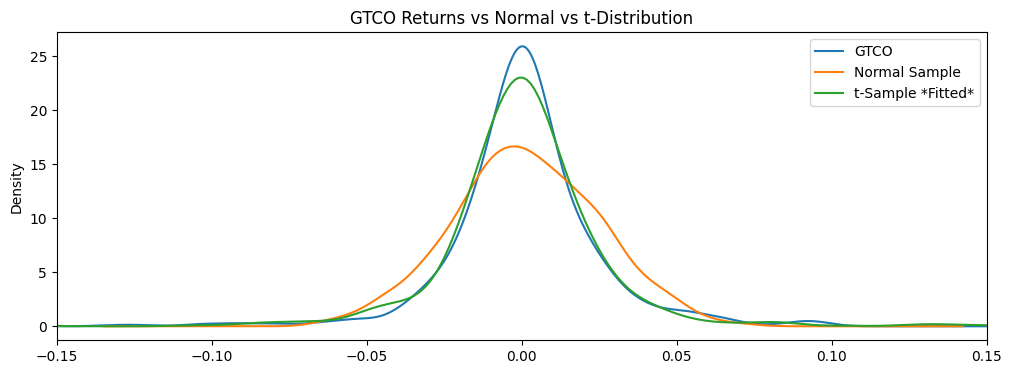

In [54]:
# Step 1: Remove zero returns before fitting
gt_returns = df_return['GTCO']
gt_clean = gt_returns[gt_returns != 0].dropna()

print(f"Original rows: {len(gt_returns)}")
print(f"After removing zeros: {len(gt_clean)}")
print(gt_clean.describe())

# Step 2: Fit t-distribution to cleaned returns
params = stats.t.fit(gt_clean)
print(f"\nFitted parameters: df={params[0]:.2f}, loc={params[1]:.6f}, scale={params[2]:.6f}")

# Step 3: Generate fitted samples
fitted_samples = stats.t.rvs(*params, size=len(gt_clean))

# Step 4: Normal distribution sample for comparison
normal_samples = np.random.normal(
    loc=gt_clean.mean(),
    scale=gt_clean.std(),
    size=len(gt_clean)
)

# Step 5: Plot
plot_df = pd.DataFrame({
    'GTCO': gt_clean.values,
    'Normal Sample': normal_samples,
    't-Sample *Fitted*': fitted_samples
})

plot_df.plot(kind='kde', figsize=(12, 4), xlim=(-0.15, 0.15))
plt.title('GTCO Returns vs Normal vs t-Distribution')
plt.show()

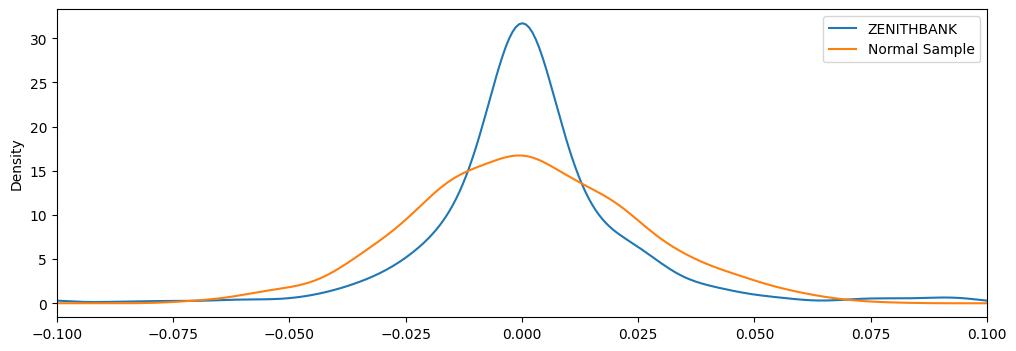

In [55]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['ZENITHBANK'] ), loc = df_return['ZENITHBANK'].mean(), scale = df_return['ZENITHBANK'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['ZENITHBANK', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

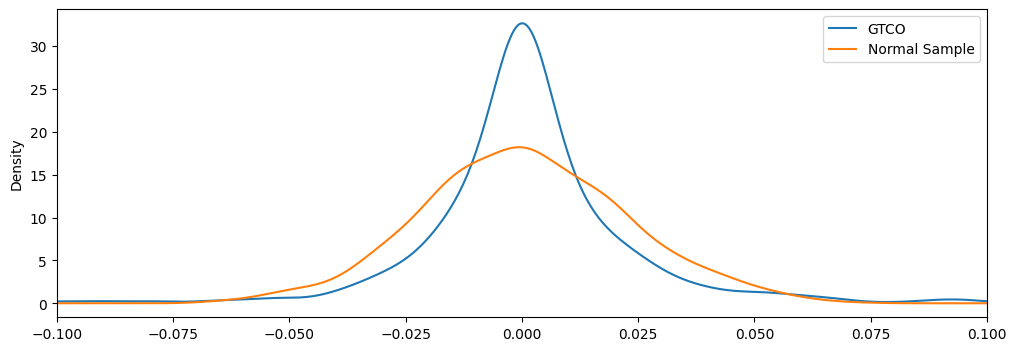

In [56]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['GTCO'] ), loc = df_return['GTCO'].mean(), scale = df_return['GTCO'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['GTCO', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

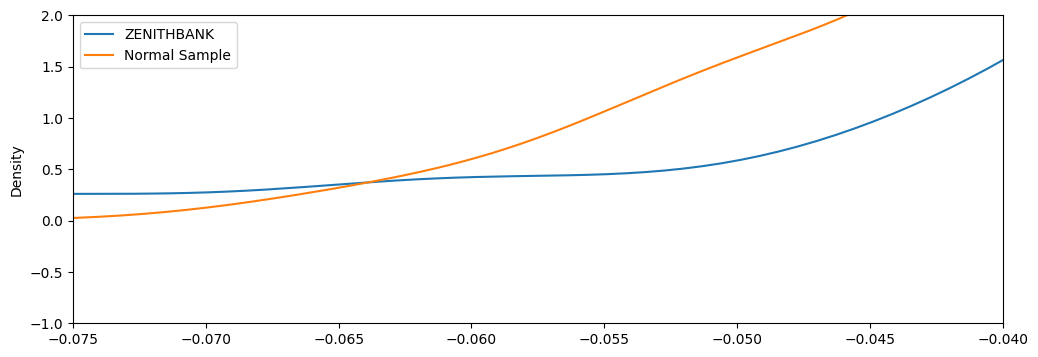

In [57]:
df_return[['ZENITHBANK', 'Normal Sample']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

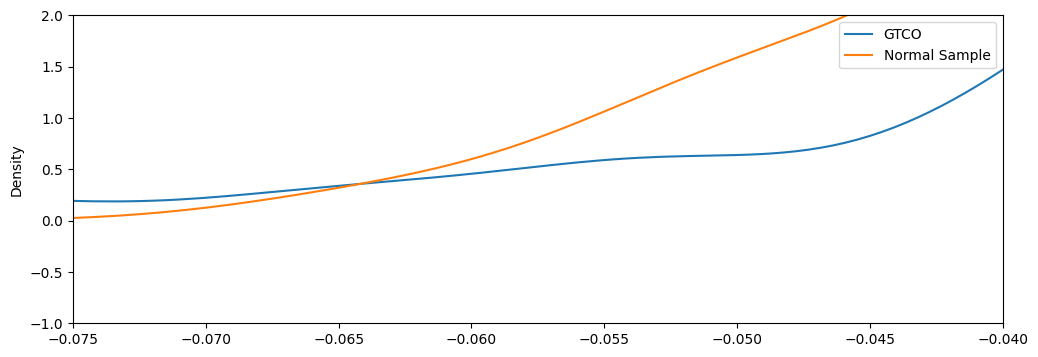

In [58]:
df_return[['GTCO', 'Normal Sample']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

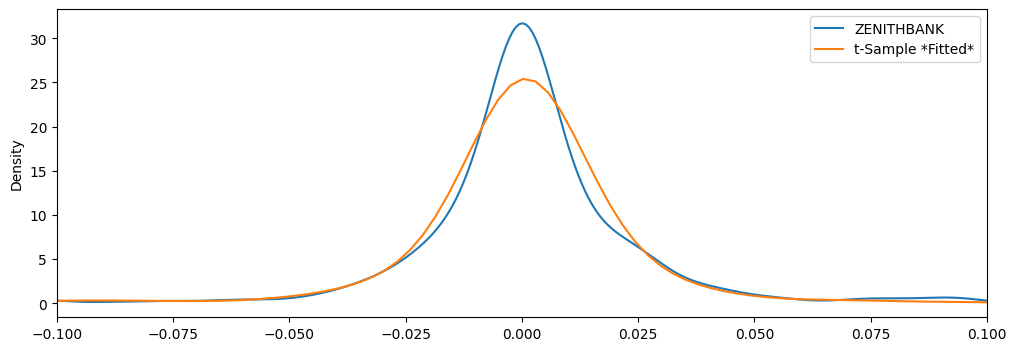

In [59]:
# Fit the t-distribution using MLE
params = stats.t.fit(df_return['ZENITHBANK'])

# We plot the fitted distribution against the kde of the data
df_return['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df_return))
df_return[['ZENITHBANK', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));

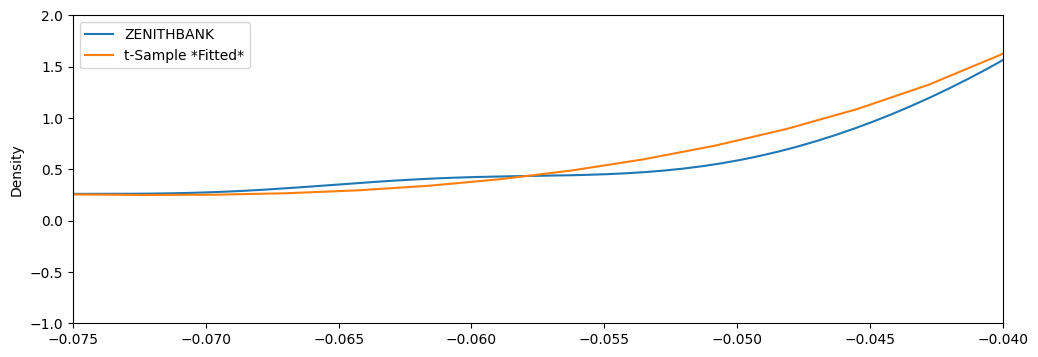

In [60]:
# Plot left tail area
df_return[['ZENITHBANK', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

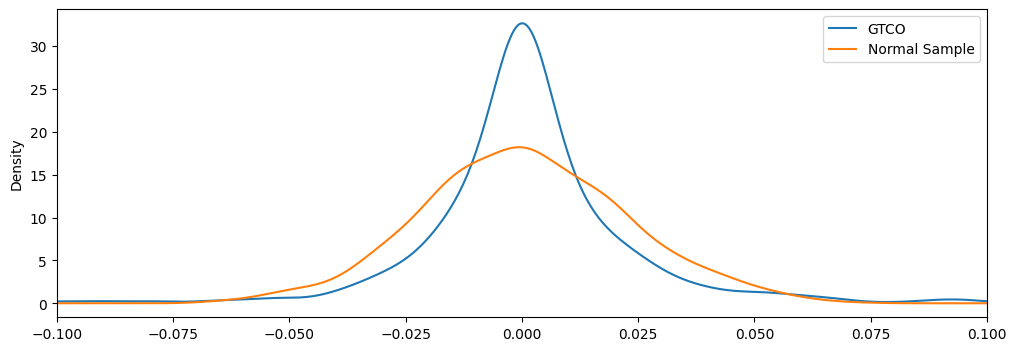

In [61]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['GTCO'] ), loc = df_return['GTCO'].mean(), scale = df_return['GTCO'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['GTCO', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

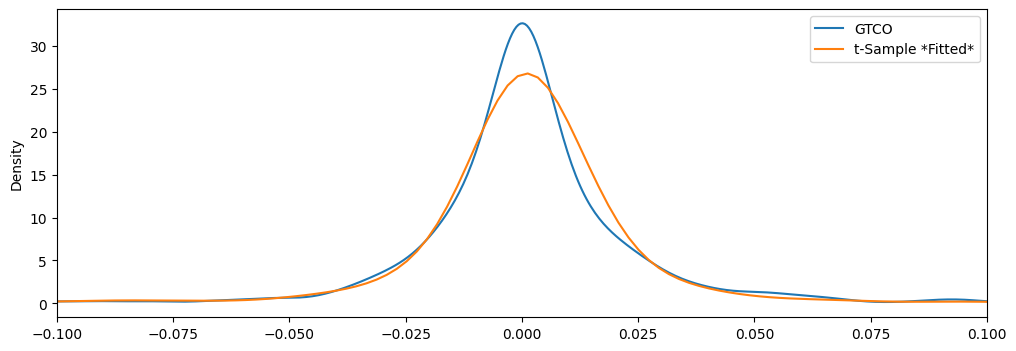

In [62]:
# Fit the t-distribution using MLE
params = stats.t.fit(df_return['GTCO'])

# We plot the fitted distribution against the kde of the data
df_return['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df_return))
df_return[['GTCO', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));

In [63]:
def is_positive_definite(matrix):
    return np.all(np.linalg.eigvals(matrix) > 0)

A = df_return.corr()

print("Is A positive definite?", is_positive_definite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive definite? True
Eigenvalues: [1.59718008 0.40429475 0.94776066 1.05089425 0.99987026]
Determinant: 0.6430627231290069
Rank: 5


In [64]:
def is_positive_semidefinite(matrix):
    return np.all(np.linalg.eigvals(matrix) >= 0)

A = df_return.corr()

print("Is A positive semidefinite?", is_positive_semidefinite(A))
print("Eigenvalues:", np.linalg.eigvals(A))
print("Determinant:", np.linalg.det(A))
print("Rank:", np.linalg.matrix_rank(A))

Is A positive semidefinite? True
Eigenvalues: [1.59718008 0.40429475 0.94776066 1.05089425 0.99987026]
Determinant: 0.6430627231290069
Rank: 5


In [65]:
new_corr = df_return[['GTCO', 'ZENITHBANK']].corr()
new_corr

,GTCO,ZENITHBANK
GTCO,1.000000,0.594895
ZENITHBANK,0.594895,1.000000


In [66]:
# Create a function to generate random samples for the given stock pair
def generate_correlated_stock_samples(n_samples, stock_returns):

    # Compute correlation matrix
    correlation_matrix = stock_returns.corr()

    # Compute Cholesky factorization
    L = np.linalg.cholesky(correlation_matrix)

    # Generate independent standard normal samples
    Z = np.random.standard_normal((correlation_matrix.shape[0], n_samples))

    # Generate correlated samples
    X = L @ Z

    # Convert to DataFrame with appropriate column names
    result = pd.DataFrame(X.T, columns=stock_returns.columns)

    return result

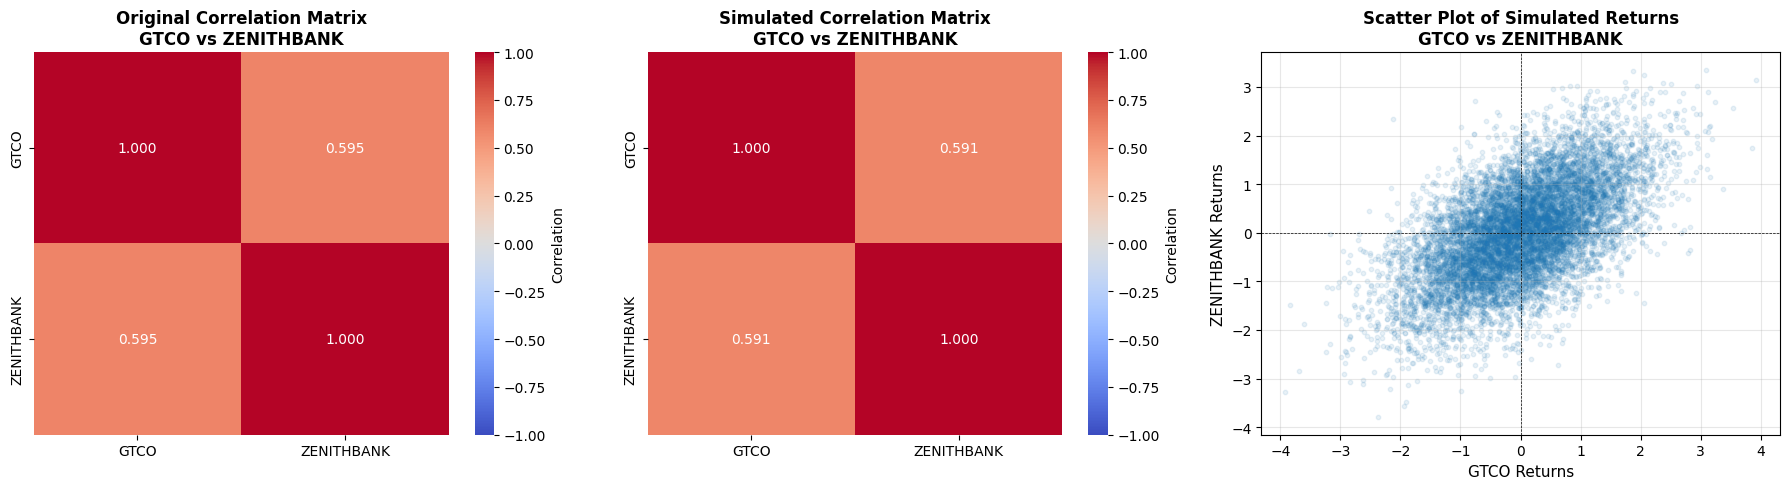


 Visualization shows the correlation structure for your assigned pair: GTCO and ZENITHBANK
   Notice how the scatter plot shape reflects the correlation coefficient of 0.595


In [67]:
np.random.seed(42)
stock1, stock2 = 'GTCO', 'ZENITHBANK'
vis_samples = generate_correlated_stock_samples(10000, df_return[['GTCO', 'ZENITHBANK']])

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original correlation heatmap
sns.heatmap(new_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[0], fmt='.3f', cbar_kws={'label': 'Correlation'})
axes[0].set_title(f'Original Correlation Matrix\n{stock1} vs {stock2}', fontsize=12, fontweight='bold')

# Plot 2: Sample correlation heatmap
sample_corr_vis = vis_samples.corr()
sns.heatmap(sample_corr_vis, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[1], fmt='.3f', cbar_kws={'label': 'Correlation'})
axes[1].set_title(f'Simulated Correlation Matrix\n{stock1} vs {stock2}', fontsize=12, fontweight='bold')

# Plot 3: Scatter plot
axes[2].scatter(vis_samples.iloc[:, 0], vis_samples.iloc[:, 1], alpha=0.1, s=10)
axes[2].set_xlabel(f'{stock1} Returns', fontsize=11)
axes[2].set_ylabel(f'{stock2} Returns', fontsize=11)
axes[2].set_title(f'Scatter Plot of Simulated Returns\n{stock1} vs {stock2}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[2].axvline(x=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\n Visualization shows the correlation structure for your assigned pair: {stock1} and {stock2}")
print(f"   Notice how the scatter plot shape reflects the correlation coefficient of {new_corr.iloc[0, 1]:.3f}")


In [68]:
np.random.seed(42)
# Test each sample size
sample_sizes = [100, 1000, 3000, 5000, 10000, 20000]
original_corr = new_corr.iloc[0, 1]
target = 0.01

for n in sample_sizes:
    samples = generate_correlated_stock_samples(n, df_return[['GTCO', 'ZENITHBANK']])
    sample_corr = samples.corr().iloc[0, 1]
    diff = abs(original_corr - sample_corr)
    print(f"n={n}: sample_corr={round(sample_corr,4)}, diff={round(diff,4)}, within 0.01: {diff < target}")

# Find minimum sample size that achieves accuracy
for n in sample_sizes:
    samples = generate_correlated_stock_samples(n, df_return[['GTCO', 'ZENITHBANK']])
    sample_corr = samples.corr().iloc[0, 1]
    diff = abs(original_corr - sample_corr)
    if diff < target:
        print(f"\nMinimum sample size: {n}")
        break

n=100: sample_corr=0.4976, diff=0.0973, within 0.01: False
n=1000: sample_corr=0.581, diff=0.0139, within 0.01: False
n=3000: sample_corr=0.5894, diff=0.0055, within 0.01: True
n=5000: sample_corr=0.5998, diff=0.0049, within 0.01: True
n=10000: sample_corr=0.5914, diff=0.0035, within 0.01: True
n=20000: sample_corr=0.6018, diff=0.0069, within 0.01: True

Minimum sample size: 1000


In [69]:
def calculate_minimum_variance_weights(simulated_returns):
    # Step 1: Calculate covariance matrix from simulated returns
    cov_matrix = df_return[['GTCO', 'ZENITHBANK']].cov()

    # Step 2: Extract individual variances and covariance
    sigma1_sq = cov_matrix.iloc[0, 0]  # variance of stock 1
    sigma2_sq = cov_matrix.iloc[1, 1]  # variance of stock 2
    sigma12   = cov_matrix.iloc[0, 1]  # covariance between stocks

    # Step 3: Apply minimum variance formula
    w1 = (sigma2_sq - sigma12) / (sigma1_sq + sigma2_sq - 2 * sigma12)
    w2 = 1 - w1

    # Step 4: Return as pandas Series with stock tickers as index
    weights = pd.Series(
        [w1, w2],
        index=simulated_returns.columns
    )

    return weights

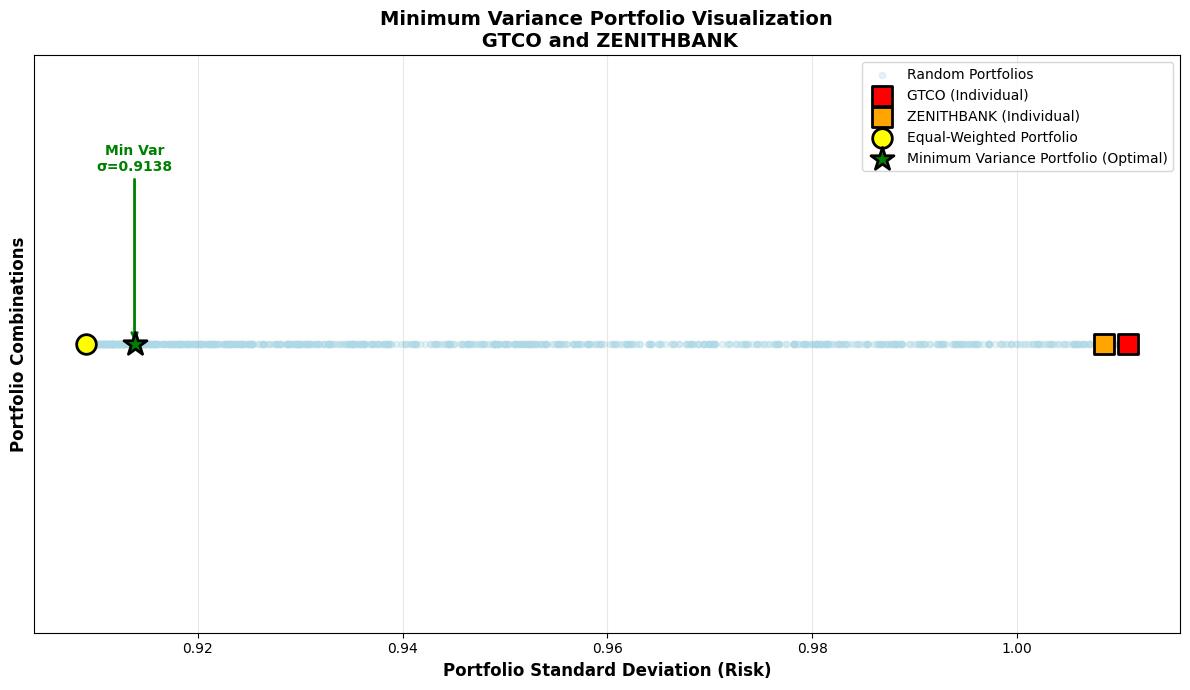


 Interpretation:
   The green star shows your optimal minimum variance portfolio.
   It has the LOWEST risk (standard deviation) among all possible
   two-stock portfolios with GTCO and ZENITHBANK.

   Notice how diversification (combining stocks) can reduce risk below
   the individual stock levels!


In [70]:
# Generate many portfolio combinations
n_portfolios = 1000
weights_array = np.random.dirichlet(np.ones(2), n_portfolios)

# Calculate covariance matrix
test_simulated_returns = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
cov_matrix = test_simulated_returns.cov()

# Calculate portfolio statistics for each combination
portfolio_returns = []
portfolio_stds = []

for weights in weights_array:
    # Portfolio variance and std dev
    port_var = weights @ cov_matrix.values @ weights
    port_std = np.sqrt(port_var)
    portfolio_stds.append(port_std)

# Get optimal weights
optimal_weights = calculate_minimum_variance_weights(test_simulated_returns)
optimal_var = optimal_weights.values @ cov_matrix.values @ optimal_weights.values
optimal_std = np.sqrt(optimal_var)

# Equal weights
equal_weights_array = np.array([0.5, 0.5])
equal_var = equal_weights_array @ cov_matrix.values @ equal_weights_array
equal_std = np.sqrt(equal_var)

# Individual stocks
stock_vars = np.diag(cov_matrix)
stock_stds = np.sqrt(stock_vars)

# Create visualization
plt.figure(figsize=(12, 7))

# Plot random portfolios
plt.scatter(portfolio_stds, [0]*len(portfolio_stds), alpha=0.3, s=20,
            label='Random Portfolios', color='lightblue')

# Plot individual stocks
plt.scatter(stock_stds[0], 0, s=200, marker='s', color='red',
            label=f'GTCO (Individual)', zorder=5, edgecolors='black', linewidth=2)
plt.scatter(stock_stds[1], 0, s=200, marker='s', color='orange',
            label=f'ZENITHBANK (Individual)', zorder=5, edgecolors='black', linewidth=2)

# Plot equal-weighted portfolio
plt.scatter(equal_std, 0, s=200, marker='o', color='yellow',
            label='Equal-Weighted Portfolio', zorder=5, edgecolors='black', linewidth=2)

# Plot optimal minimum variance portfolio
plt.scatter(optimal_std, 0, s=300, marker='*', color='green',
            label='Minimum Variance Portfolio (Optimal)', zorder=10, edgecolors='black', linewidth=2)

plt.xlabel('Portfolio Standard Deviation (Risk)', fontsize=12, fontweight='bold')
plt.ylabel('Portfolio Combinations', fontsize=12, fontweight='bold')
plt.title(f'Minimum Variance Portfolio Visualization\n GTCO and ZENITHBANK',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 0.5)
plt.yticks([])

# Add annotations
plt.annotate(f'Min Var\nσ={optimal_std:.4f}',
             xy=(optimal_std, 0), xytext=(optimal_std, 0.3),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=10, ha='center', fontweight='bold', color='green')

plt.tight_layout()
plt.show()

print("\n Interpretation:")
print(f"   The green star shows your optimal minimum variance portfolio.")
print(f"   It has the LOWEST risk (standard deviation) among all possible")
print(f"   two-stock portfolios with GTCO and ZENITHBANK.")
print(f"\n   Notice how diversification (combining stocks) can reduce risk below")
print(f"   the individual stock levels!")

In [71]:
# Use this cell to calculate your answer
# Generate samples and get optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

print(f"Optimal weights: {optimal_weights.values.round(4)}")

# Calculate ENB
ENB = 1 / np.sum(optimal_weights ** 2)
print(f"ENB = 1 / ({round(optimal_weights.iloc[0]**2, 4)} + {round(optimal_weights.iloc[1]**2, 4)})")
print(f"ENB = {round(ENB, 4)}")

Optimal weights: [0.6031 0.3969]
ENB = 1 / (0.3637 + 0.1575)
ENB = 1.9184


In [72]:
# Use this cell to calculate your answer

# Generate samples and get optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Step 1: Covariance matrix
cov_matrix = samples.cov().values

# Step 2: Weight vector
w = optimal_weights.values

# Step 3: Compute covariance matrix × weights
cov_w = cov_matrix @ w

# Step 4: First element (MCR for stock 1)
cov_w_1 = cov_w[0]

# Step 5: Portfolio standard deviation
portfolio_variance = w.T @ cov_matrix @ w
portfolio_std = np.sqrt(portfolio_variance)
print(f"Portfolio std dev: {round(portfolio_std, 6)}")

# Step 6: MCR for stock 1
MCR_1 = cov_w_1 / portfolio_std
print(f"MCR of GTCO: {round(MCR_1, 6)}")

Portfolio std dev: 0.885547
MCR of GTCO: 0.919338


In [73]:
# FD-GCA-M2-Q9 Coding task starter code

def calculate_portfolio_var(simulated_returns, weights, confidence_levels):
    # Step 1: Convert weights to numpy array (handles both Series and ndarray)
    if isinstance(weights, pd.Series):
        w = weights.values
    else:
        w = np.array(weights)

    # Step 2: Calculate portfolio returns (weighted sum of stock returns)
    # Each row is one simulated day, multiply each stock return by its weight
    portfolio_returns = simulated_returns.values @ w

    # Step 3: Portfolio statistics
    portfolio_mean = float(np.mean(portfolio_returns))
    portfolio_std = float(np.std(portfolio_returns, ddof=1))

    # Step 4: Calculate VaR for each confidence level
    var_dict = {}
    for confidence in confidence_levels:
        # 95% VaR uses 5th percentile, 99% VaR uses 1st percentile
        percentile = (1 - confidence) * 100
        var_value = -np.percentile(portfolio_returns, percentile)
        var_dict[confidence] = float(var_value)

    # Step 5: Return results dictionary
    return {
        'portfolio_returns': portfolio_returns,
        'portfolio_mean':    portfolio_mean,
        'portfolio_std':     portfolio_std,
        'VaR':               var_dict
    }


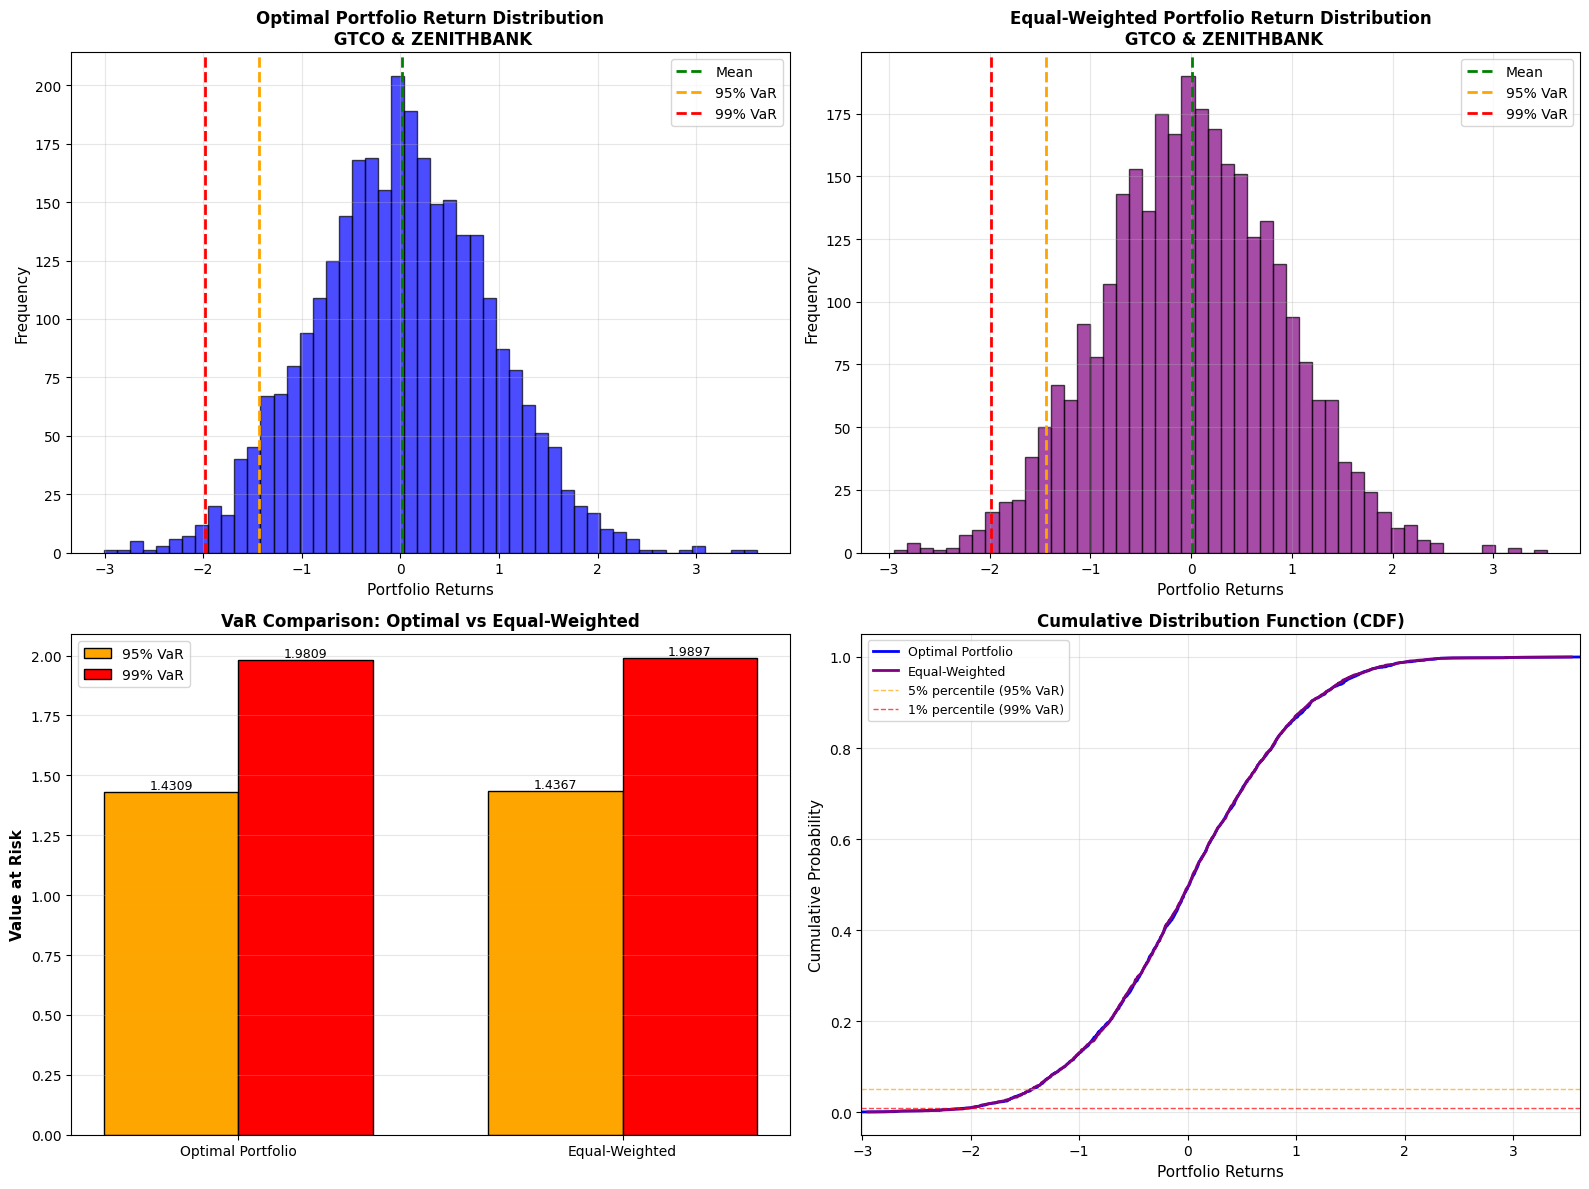


📊 COMPREHENSIVE RISK COMPARISON

🎯 OPTIMAL PORTFOLIO (Minimum Variance):
   Weights: [0.60311474 0.39688526]
   Mean Return: 0.014655
   Std Deviation: 0.885547
   95% VaR: 1.430889 (143.089%)
   99% VaR: 1.980947 (198.095%)

⚖️  EQUAL-WEIGHTED PORTFOLIO:
   Weights: [0.5 0.5]
   Mean Return: 0.010149
   Std Deviation: 0.881705
   95% VaR: 1.436736 (143.674%)
   99% VaR: 1.989677 (198.968%)

📉 RISK REDUCTION (Optimal vs Equal-Weighted):
   Volatility Reduction: -0.44%
   95% VaR Reduction: 0.41%
   99% VaR Reduction: 0.44%

💡 INTERPRETATION:
   The optimal portfolio achieves lower risk (VaR) through strategic allocation
   based on the correlation structure between the two stocks.
   This demonstrates the power of Modern Portfolio Theory and Monte Carlo
   simulation in quantitative risk management!


In [74]:
# Comprehensive Visualization of Portfolio Risk

# Generate results for visualization
np.random.seed(42)
vis_simulated_returns = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
vis_optimal_weights = calculate_minimum_variance_weights(vis_simulated_returns)
vis_equal_weights = pd.Series([0.5, 0.5], index=vis_simulated_returns.columns)

# Calculate VaR for both portfolios
optimal_var_result = calculate_portfolio_var(vis_simulated_returns, vis_optimal_weights, [0.95, 0.99])
equal_var_result = calculate_portfolio_var(vis_simulated_returns, vis_equal_weights, [0.95, 0.99])

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Distribution of portfolio returns (Optimal)
ax1 = axes[0, 0]
ax1.hist(optimal_var_result['portfolio_returns'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(optimal_var_result['portfolio_mean'], color='green', linestyle='--', linewidth=2, label='Mean')
ax1.axvline(-optimal_var_result['VaR'][0.95], color='orange', linestyle='--', linewidth=2, label='95% VaR')
ax1.axvline(-optimal_var_result['VaR'][0.99], color='red', linestyle='--', linewidth=2, label='99% VaR')
ax1.set_xlabel('Portfolio Returns', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title(f'Optimal Portfolio Return Distribution\n GTCO & ZENITHBANK',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of portfolio returns (Equal-weighted)
ax2 = axes[0, 1]
ax2.hist(equal_var_result['portfolio_returns'], bins=50, alpha=0.7, color='purple', edgecolor='black')
ax2.axvline(equal_var_result['portfolio_mean'], color='green', linestyle='--', linewidth=2, label='Mean')
ax2.axvline(-equal_var_result['VaR'][0.95], color='orange', linestyle='--', linewidth=2, label='95% VaR')
ax2.axvline(-equal_var_result['VaR'][0.99], color='red', linestyle='--', linewidth=2, label='99% VaR')
ax2.set_xlabel('Portfolio Returns', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title(f'Equal-Weighted Portfolio Return Distribution\n GTCO & ZENITHBANK',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: VaR Comparison
ax3 = axes[1, 0]
x_pos = np.arange(2)
var_95_values = [optimal_var_result['VaR'][0.95], equal_var_result['VaR'][0.95]]
var_99_values = [optimal_var_result['VaR'][0.99], equal_var_result['VaR'][0.99]]

width = 0.35
bars1 = ax3.bar(x_pos - width/2, var_95_values, width, label='95% VaR', color='orange', edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, var_99_values, width, label='99% VaR', color='red', edgecolor='black')

ax3.set_ylabel('Value at Risk', fontsize=11, fontweight='bold')
ax3.set_title('VaR Comparison: Optimal vs Equal-Weighted', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Optimal Portfolio', 'Equal-Weighted'], fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

# Plot 4: Cumulative Distribution Function (CDF)
ax4 = axes[1, 1]
sorted_optimal = np.sort(optimal_var_result['portfolio_returns'])
sorted_equal = np.sort(equal_var_result['portfolio_returns'])
cdf_optimal = np.arange(1, len(sorted_optimal)+1) / len(sorted_optimal)
cdf_equal = np.arange(1, len(sorted_equal)+1) / len(sorted_equal)

ax4.plot(sorted_optimal, cdf_optimal, label='Optimal Portfolio', linewidth=2, color='blue')
ax4.plot(sorted_equal, cdf_equal, label='Equal-Weighted', linewidth=2, color='purple')

# Mark VaR levels
ax4.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='5% percentile (95% VaR)')
ax4.axhline(y=0.01, color='red', linestyle='--', linewidth=1, alpha=0.7, label='1% percentile (99% VaR)')

ax4.set_xlabel('Portfolio Returns', fontsize=11)
ax4.set_ylabel('Cumulative Probability', fontsize=11)
ax4.set_title('Cumulative Distribution Function (CDF)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim([sorted_optimal[0], sorted_optimal[-1]])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("📊 COMPREHENSIVE RISK COMPARISON")
print("="*70)

print("\n🎯 OPTIMAL PORTFOLIO (Minimum Variance):")
print(f"   Weights: {vis_optimal_weights.values}")
print(f"   Mean Return: {optimal_var_result['portfolio_mean']:.6f}")
print(f"   Std Deviation: {optimal_var_result['portfolio_std']:.6f}")
print(f"   95% VaR: {optimal_var_result['VaR'][0.95]:.6f} ({optimal_var_result['VaR'][0.95]*100:.3f}%)")
print(f"   99% VaR: {optimal_var_result['VaR'][0.99]:.6f} ({optimal_var_result['VaR'][0.99]*100:.3f}%)")

print("\n⚖️  EQUAL-WEIGHTED PORTFOLIO:")
print(f"   Weights: {vis_equal_weights.values}")
print(f"   Mean Return: {equal_var_result['portfolio_mean']:.6f}")
print(f"   Std Deviation: {equal_var_result['portfolio_std']:.6f}")
print(f"   95% VaR: {equal_var_result['VaR'][0.95]:.6f} ({equal_var_result['VaR'][0.95]*100:.3f}%)")
print(f"   99% VaR: {equal_var_result['VaR'][0.99]:.6f} ({equal_var_result['VaR'][0.99]*100:.3f}%)")

print("\n📉 RISK REDUCTION (Optimal vs Equal-Weighted):")
std_reduction = ((equal_var_result['portfolio_std'] - optimal_var_result['portfolio_std']) /
                 equal_var_result['portfolio_std']) * 100
var95_reduction = ((equal_var_result['VaR'][0.95] - optimal_var_result['VaR'][0.95]) /
                   equal_var_result['VaR'][0.95]) * 100
var99_reduction = ((equal_var_result['VaR'][0.99] - optimal_var_result['VaR'][0.99]) /
                   equal_var_result['VaR'][0.99]) * 100

print(f"   Volatility Reduction: {std_reduction:.2f}%")
print(f"   95% VaR Reduction: {var95_reduction:.2f}%")
print(f"   99% VaR Reduction: {var99_reduction:.2f}%")

print("\n💡 INTERPRETATION:")
print("   The optimal portfolio achieves lower risk (VaR) through strategic allocation")
print("   based on the correlation structure between the two stocks.")
print("   This demonstrates the power of Modern Portfolio Theory and Monte Carlo")
print("   simulation in quantitative risk management!")
print("="*70)

In [75]:
# Generate samples and optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Get portfolio returns
risk_metrics = calculate_portfolio_var(
    simulated_returns=samples,
    weights=optimal_weights,
    confidence_levels=[0.95, 0.99]
)

portfolio_returns = risk_metrics['portfolio_returns']
var_95 = risk_metrics['VaR'][0.95]
print(f"95% VaR: {round(var_95, 6)}")

# Expected Shortfall — average of returns BELOW the VaR threshold
threshold = -var_95
tail_returns = portfolio_returns[portfolio_returns <= threshold]
ES_95 = -np.mean(tail_returns)

print(f"Number of tail returns: {len(tail_returns)}")
print(f"95% Expected Shortfall: {round(ES_95, 6)}")

95% VaR: 1.430889
Number of tail returns: 150
95% Expected Shortfall: 1.788378


In [76]:
# Use this cell to calculate your answer

# Generate samples and optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Get portfolio returns and VaR
risk_metrics = calculate_portfolio_var(
    simulated_returns=samples,
    weights=optimal_weights,
    confidence_levels=[0.95, 0.99]
)

portfolio_returns = risk_metrics['portfolio_returns']
var_95 = risk_metrics['VaR'][0.95]

# Count exceedances — returns that fell BELOW the VaR threshold
exceedances = np.sum(portfolio_returns <= -var_95)
print(f"95% VaR threshold: {round(-var_95, 6)}")
print(f"Number of exceedances: {exceedances}")
print(f"Expected exceedances (5% of 3000): {int(3000 * 0.05)}")
print(f"Actual exceedance rate: {round(exceedances/3000*100, 2)}%")

95% VaR threshold: -1.430889
Number of exceedances: 150
Expected exceedances (5% of 3000): 150
Actual exceedance rate: 5.0%


In [77]:
# Use this cell to calculate your answer

# Generate samples and optimal weights
np.random.seed(42)
samples = generate_correlated_stock_samples(3000, df_return[['GTCO', 'ZENITHBANK']])
optimal_weights = calculate_minimum_variance_weights(samples)

# Get portfolio returns and 99% VaR
risk_metrics = calculate_portfolio_var(
    simulated_returns=samples,
    weights=optimal_weights,
    confidence_levels=[0.95, 0.99]
)

portfolio_returns = risk_metrics['portfolio_returns']
var_99 = risk_metrics['VaR'][0.99]

# Calculate 99% ES
threshold_99 = -var_99
tail_returns_99 = portfolio_returns[portfolio_returns <= threshold_99]
ES_99 = -np.mean(tail_returns_99)

# Calculate ES/VaR ratio
ratio = ES_99 / var_99

print(f"99% VaR: {round(var_99, 6)}")
print(f"99% ES:  {round(ES_99, 6)}")
print(f"ES/VaR ratio: {round(ratio, 4)}")

99% VaR: 1.980947
99% ES:  2.32522
ES/VaR ratio: 1.1738
